# Q5 Kaggle — Twitter Bot vs. Genuine User Classification

**Competition:** CS610 Assignment 1 Question 5 (2026)
**Evaluation metric:** AUC (Area Under ROC Curve)
**Submission format:** `index,target` — where `target` is a probability in `[0, 1]`

This notebook walks through baseline → LightGBM → cross-validation → text features → temporal features → Optuna tuning. Each section adds one specific change and validates it through CV before submitting.


## 1. Setup

In [ ]:
from pathlib import Path
import warnings, logging

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from scipy import sparse

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 2025

#test 

In [46]:
HERE = Path.cwd()
REPO = HERE.parent if HERE.name == "q5_kaggle" else HERE
DATA_DIR = REPO / "Assignment1" / "cs-610-assignment-1-question-5-2026"
SUB_DIR = (HERE if HERE.name == "q5_kaggle" else HERE / "q5_kaggle") / "submissions"
SUB_DIR.mkdir(exist_ok=True, parents=True)
print("Data dir :", DATA_DIR)
print("Sub  dir :", SUB_DIR)


Data dir : C:\Users\user\Desktop\6. AML\AML_rep\Assignment1\cs-610-assignment-1-question-5-2026
Sub  dir : C:\Users\user\Desktop\6. AML\AML_rep\q5_kaggle\submissions


## 2. Load and inspect

In [47]:
train = pd.read_csv(DATA_DIR / "train.csv")
test  = pd.read_csv(DATA_DIR / "test.csv")
print(f"train: {train.shape}")
print(f"test : {test.shape}")
train.head()


train: (26206, 19)
test : (11232, 19)


,created_at,default_profile,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,id,lang,location,profile_background_image_url,profile_image_url,screen_name,statuses_count,verified,average_tweets_per_day,account_age_days,target
0,2012-01-15 23:40:09,True,False,Cosplayer/Fitness lover. Come to me https://t....,74,7,0,False,465096524,en,unknown,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/9666745212...,reml5477,20,False,0.006,3138,1
1,2016-10-04 00:44:39,False,False,pobody’s nerfect,50443,164,590,True,783105517673648132,cy,she/her,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/1281752126...,kinlibra,6469,False,4.572,1415,0
2,2009-05-23 04:04:13,False,False,gracias por participar 🏅,9394,208,189,False,41970759,es,La diaspora,http://abs.twimg.com/images/themes/theme17/bg.gif,http://pbs.twimg.com/profile_images/1233811596...,_delaualau,30296,False,7.378,4106,0
3,2009-05-17 04:31:31,False,False,Stand Up Comedian/Actor from North Philadelphi...,46,66180,1090,True,40607946,en,"Calabasas, CA",http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/1184851104...,SpankHorton,164957,False,40.116,4112,0
4,2009-02-16 13:11:21,True,False,Assignment Editor at NBC10 and President of Ja...,1223,487,867,True,20983433,en,"Jenkintown, PA",http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/5234863934...,javelinjt,1752,False,0.417,4201,0


In [48]:
print(train["target"].value_counts())
print(f"\nbot rate: {train['target'].mean():.3f}")


target
0    17423
1     8783
Name: count, dtype: int64

bot rate: 0.335


In [49]:
pd.DataFrame({
    "dtype":       train.dtypes,
    "missing":     train.isna().sum(),
    "pct_missing": (train.isna().mean() * 100).round(2),
    "nunique":     train.nunique(),
})


,dtype,missing,pct_missing,nunique
created_at,object,0,0.00,26205
default_profile,bool,0,0.00,2
default_profile_image,bool,0,0.00,2
description,object,5091,19.43,20988
favourites_count,int64,0,0.00,11679
followers_count,int64,0,0.00,9770
friends_count,int64,0,0.00,4372
geo_enabled,bool,0,0.00,2
id,int64,0,0.00,26206
lang,object,5588,21.32,48


- Class imbalance is mild (33% bots). AUC is robust to imbalance.
- `description` and `lang` ~20% missing — impute + presence flags.
- `screen_name` is unique per row — extract length/digit-fraction patterns.
- `profile_background_image_url` has 20 unique values — Twitter defaults.
- `id` is unique — drop. `created_at` — handled in §9.


## 3. Feature engineering

The raw columns aren't directly usable. We tame heavy-tailed counts with `log1p`, convert booleans to int, bucket high-cardinality `lang` to top-8 + `OTHER`, extract cheap text features, and add ratio features.


In [50]:
TOP_LANGS = train["lang"].value_counts().head(8).index.tolist()
print("Top 8 langs:", TOP_LANGS)


Top 8 langs: ['en', 'es', 'pt', 'it', 'ar', 'de', 'fr', 'ja']


In [51]:
def featurize(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    counts = ["favourites_count", "followers_count", "friends_count",
              "statuses_count", "average_tweets_per_day", "account_age_days"]
    for c in counts:
        out[c] = df[c].astype(float)
    for c in ["favourites_count", "followers_count", "friends_count", "statuses_count"]:
        out[f"log_{c}"] = np.log1p(out[c])
    for c in ["default_profile", "default_profile_image", "geo_enabled", "verified"]:
        out[c] = df[c].astype(int)
    out["has_description"] = df["description"].notna().astype(int)
    out["has_location"]    = (df["location"].notna() & (df["location"] != "unknown")).astype(int)
    out["has_url_bg"]      = df["profile_background_image_url"].notna().astype(int)
    out["desc_len"]  = df["description"].fillna("").str.len()
    out["sn_len"]    = df["screen_name"].fillna("").str.len()
    out["sn_digits"] = (df["screen_name"].fillna("").str.count(r"\d") / out["sn_len"].clip(lower=1))
    lang = df["lang"].fillna("MISSING")
    out["lang"] = lang.where(lang.isin(TOP_LANGS), "OTHER")
    out["followers_per_friend"] = df["followers_count"] / df["friends_count"].clip(lower=1)
    out["statuses_per_day"]     = df["statuses_count"]  / df["account_age_days"].clip(lower=1)
    return out

X_train_full = featurize(train)
y_train      = train["target"].values
X_test       = featurize(test)
print(f"feature matrix: train {X_train_full.shape}, test {X_test.shape}")


feature matrix: train (26206, 23), test (11232, 23)


## 4. Train/validation split

In [52]:
Xa, Xb, ya, yb = train_test_split(
    X_train_full, y_train,
    test_size=0.2, stratify=y_train, random_state=RANDOM_STATE,
)
print(f"train: {Xa.shape}  val: {Xb.shape}")


train: (20964, 23)  val: (5242, 23)


## 5. LogReg + Random Forest baseline

Two preprocessors: LogReg needs scaled numerics + one-hot lang; RF only needs one-hot lang.


In [53]:
numeric_cols     = [c for c in X_train_full.columns if c != "lang"]
categorical_cols = ["lang"]

preproc_lr = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale",  StandardScaler())]), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

preproc_rf = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

models = {
    "logreg": Pipeline([("preproc", preproc_lr),
                        ("clf", LogisticRegression(max_iter=2000, C=1.0,
                                                   random_state=RANDOM_STATE))]),
    "rf": Pipeline([("preproc", preproc_rf),
                    ("clf", RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                                   n_jobs=-1, random_state=RANDOM_STATE))]),
}

scores = {}
for name, pipe in models.items():
    pipe.fit(Xa, ya)
    yb_prob = pipe.predict_proba(Xb)[:, 1]
    yb_pred = (yb_prob >= 0.5).astype(int)
    auc = roc_auc_score(yb, yb_prob); f1 = f1_score(yb, yb_pred)
    scores[name] = {"auc": auc, "f1": f1}
    print(f"=== {name.upper()} ===   AUC: {auc:.4f}   F1: {f1:.4f}")


=== LOGREG ===   AUC: 0.8598   F1: 0.6929
=== RF ===   AUC: 0.9404   F1: 0.8077


In [54]:
winner = max(scores, key=lambda k: scores[k]["auc"])
best = models[winner]
best.fit(X_train_full, y_train)
test_prob = best.predict_proba(X_test)[:, 1]
sub = pd.DataFrame({"index": test["index"].values, "target": test_prob})
sub.to_csv(SUB_DIR / f"baseline_{winner}.csv", index=False, float_format="%.6f")
print(f"Wrote: {SUB_DIR / f'baseline_{winner}.csv'}")


Wrote: C:\Users\user\Desktop\6. AML\AML_rep\q5_kaggle\submissions\baseline_rf.csv


## 6. Upgrade to LightGBM

GBM trains trees sequentially — each new tree fits the residual errors of the previous trees. Two LightGBM features that help: native categorical handling (`lang` as `category`), and early stopping (library picks the right number of trees from `eval_set`).


In [55]:
import lightgbm as lgb

def to_lgb_input(X):
    out = X.copy()
    out["lang"] = out["lang"].astype("category")
    return out

X_lgb_full = to_lgb_input(X_train_full)
X_lgb_test = to_lgb_input(X_test)
X_lgb_test["lang"] = pd.Categorical(
    X_lgb_test["lang"], categories=X_lgb_full["lang"].cat.categories
)

Xa_lgb, Xb_lgb, ya_lgb, yb_lgb = train_test_split(
    X_lgb_full, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE,
)

lgbm = lgb.LGBMClassifier(
    n_estimators=2000, learning_rate=0.05, num_leaves=63,
    min_data_in_leaf=20, feature_fraction=0.9, bagging_fraction=0.9,
    bagging_freq=5, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)
lgbm.fit(Xa_lgb, ya_lgb, eval_set=[(Xb_lgb, yb_lgb)], eval_metric="auc",
         callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])

yb_prob_lgb = lgbm.predict_proba(Xb_lgb)[:, 1]
auc_lgb = roc_auc_score(yb_lgb, yb_prob_lgb)
print(f"LightGBM holdout AUC : {auc_lgb:.4f}")
print(f"Random Forest        : {scores['rf']['auc']:.4f}")
print(f"Lift                 : {auc_lgb - scores['rf']['auc']:+.4f}")
print(f"Best iter            : {lgbm.best_iteration_}")


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[125]	valid_0's auc: 0.941776	valid_0's binary_logloss: 0.281465
LightGBM holdout AUC : 0.9418
Random Forest        : 0.9404
Lift                 : +0.0014
Best iter            : 125


In [56]:
lgbm_final = lgb.LGBMClassifier(
    n_estimators=lgbm.best_iteration_, learning_rate=0.05, num_leaves=63,
    min_data_in_leaf=20, feature_fraction=0.9, bagging_fraction=0.9, bagging_freq=5,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)
lgbm_final.fit(X_lgb_full, y_train)
test_prob_lgb = lgbm_final.predict_proba(X_lgb_test)[:, 1]
sub = pd.DataFrame({"index": test["index"].values, "target": test_prob_lgb})
sub.to_csv(SUB_DIR / "lgbm_v1.csv", index=False, float_format="%.6f")
print(f"Wrote: {SUB_DIR/'lgbm_v1.csv'}")


Wrote: C:\Users\user\Desktop\6. AML\AML_rep\q5_kaggle\submissions\lgbm_v1.csv


**Public LB:** baseline_rf.csv → 0.93470, lgbm_v1.csv → 0.93553

## 7. Stratified 5-fold cross-validation

Single 80/20 holdouts have variance — we need a stable benchmark. 5-fold CV gives us mean ± std (the std is our noise floor) and OOF predictions (one ranking across all training rows, useful later for ensembling).


In [57]:
def lgbm_cv(X, y, n_splits=5, params=None, verbose=True):
    """5-fold CV with LightGBM + early stopping. Works on DataFrame or sparse matrix."""
    p = dict(
        n_estimators=2000, learning_rate=0.05, num_leaves=63,
        min_data_in_leaf=20, feature_fraction=0.9, bagging_fraction=0.9,
        bagging_freq=5, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    )
    if params: p.update(params)

    def take(M, idx):
        return M.iloc[idx] if hasattr(M, "iloc") else M[idx]

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    aucs, iters = [], []
    n_rows = X.shape[0]
    oof = np.zeros(n_rows)

    for fold, (tr, va) in enumerate(skf.split(np.zeros(n_rows), y)):
        clf = lgb.LGBMClassifier(**p)
        clf.fit(take(X, tr), y[tr],
                eval_set=[(take(X, va), y[va])], eval_metric="auc",
                callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
        prob = clf.predict_proba(take(X, va))[:, 1]
        oof[va] = prob
        auc = roc_auc_score(y[va], prob)
        aucs.append(auc); iters.append(clf.best_iteration_)
        if verbose:
            print(f"Fold {fold+1}: AUC={auc:.4f}  best_iter={clf.best_iteration_}")

    aucs = np.array(aucs)
    if verbose:
        print(f"\nMean fold AUC : {aucs.mean():.4f} ± {aucs.std():.4f}")
        print(f"OOF AUC       : {roc_auc_score(y, oof):.4f}")
        print(f"Mean best_iter: {int(np.mean(iters))}")
    return {"aucs": aucs, "iters": iters, "oof": oof}

cv_baseline = lgbm_cv(X_lgb_full, y_train)


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[186]	valid_0's auc: 0.944342	valid_0's binary_logloss: 0.275098
Fold 1: AUC=0.9443  best_iter=186
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[224]	valid_0's auc: 0.93884	valid_0's binary_logloss: 0.287555
Fold 2: AUC=0.9388  best_iter=224
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[222]	valid_0's auc: 0.935613	valid_0's binary_logloss: 0.29653
Fold 3: AUC=0.9356  best_iter=222
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[175]	valid_0's auc: 0.944482	valid_0's binary_logloss: 0.274053
Fold 4: AUC=0.9445  best_iter=175
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[254]	valid_0's auc: 0.943025	valid_0's binary_logloss: 0.280137
Fold 5: AUC=0.9430  best_iter=254

Mean fold AUC : 0.9413 ± 0

**Benchmark:** OOF AUC ≈ 0.9411, std ≈ 0.0035.

## 8. Description text features (TF-IDF)

Bots often have empty/templated bios. TF-IDF: term frequency × inverse document frequency. Common terms get low weight, distinctive terms get high. Result is sparse.

Critical: fit TF-IDF on TRAIN only, then transform both. Fitting on test would leak test vocabulary.


In [58]:
text_train = train["description"].fillna("")
text_test  = test["description"].fillna("")

tfidf = TfidfVectorizer(
    max_features=500, ngram_range=(1, 2),
    min_df=5, max_df=0.95, lowercase=True,
    sublinear_tf=True, strip_accents="unicode",
)
Xt_train = tfidf.fit_transform(text_train)
Xt_test  = tfidf.transform(text_test)
print(f"TF-IDF: {Xt_train.shape}")


TF-IDF: (26206, 500)


In [59]:
oh = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
lang_train_oh = oh.fit_transform(X_train_full[["lang"]])
lang_test_oh  = oh.transform(X_test[["lang"]])

num_train = sparse.csr_matrix(X_train_full[numeric_cols].fillna(0).values)
num_test  = sparse.csr_matrix(X_test[numeric_cols].fillna(0).values)

X_combined_train = sparse.hstack([num_train, lang_train_oh, Xt_train]).tocsr()
X_combined_test  = sparse.hstack([num_test,  lang_test_oh,  Xt_test ]).tocsr()
print(f"Combined: {X_combined_train.shape}")


Combined: (26206, 531)


In [60]:
cv_text = lgbm_cv(X_combined_train, y_train)
print(f"\nNo text  OOF: {roc_auc_score(y_train, cv_baseline['oof']):.4f}")
print(f"With text OOF: {roc_auc_score(y_train, cv_text['oof']):.4f}")


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[149]	valid_0's auc: 0.946729	valid_0's binary_logloss: 0.270215
Fold 1: AUC=0.9467  best_iter=149
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[197]	valid_0's auc: 0.941036	valid_0's binary_logloss: 0.281675
Fold 2: AUC=0.9410  best_iter=197
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[170]	valid_0's auc: 0.937041	valid_0's binary_logloss: 0.292372
Fold 3: AUC=0.9370  best_iter=170
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[137]	valid_0's auc: 0.946343	valid_0's binary_logloss: 0.268865
Fold 4: AUC=0.9463  best_iter=137
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[175]	valid_0's auc: 0.945909	valid_0's binary_logloss: 0.271838
Fold 5: AUC=0.9459  best_iter=175

Mean fold AUC : 0.9434 ±

In [61]:
clf_v2 = lgb.LGBMClassifier(
    n_estimators=int(np.mean(cv_text["iters"])),
    learning_rate=0.05, num_leaves=63, min_data_in_leaf=20,
    feature_fraction=0.9, bagging_fraction=0.9, bagging_freq=5,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)
clf_v2.fit(X_combined_train, y_train)
test_prob = clf_v2.predict_proba(X_combined_test)[:, 1]
sub = pd.DataFrame({"index": test["index"].values, "target": test_prob})
sub.to_csv(SUB_DIR / "lgbm_v2_text.csv", index=False, float_format="%.6f")
print(f"Wrote: {SUB_DIR/'lgbm_v2_text.csv'}")


Wrote: C:\Users\user\Desktop\6. AML\AML_rep\q5_kaggle\submissions\lgbm_v2_text.csv


**Public LB:** lgbm_v2_text.csv → 0.93919

## 9. Temporal features from `created_at`

Year, month, day-of-week, hour-of-day, plus cyclical sin/cos encodings of hour and DoW. The cyclical pair lets a linear model represent "23:00 is close to 00:00" — for tree models the raw integer is fine, but we include both for ensemble robustness later.


In [62]:
def add_temporal(df: pd.DataFrame, X_dense: pd.DataFrame) -> pd.DataFrame:
    out = X_dense.copy()
    ct = pd.to_datetime(df["created_at"])
    out["created_year"]  = ct.dt.year.astype(float)
    out["created_month"] = ct.dt.month.astype(float)
    out["created_dow"]   = ct.dt.dayofweek.astype(float)
    out["created_hour"]  = ct.dt.hour.astype(float)
    out["hour_sin"] = np.sin(2*np.pi*out["created_hour"]/24)
    out["hour_cos"] = np.cos(2*np.pi*out["created_hour"]/24)
    out["dow_sin"]  = np.sin(2*np.pi*out["created_dow"]/7)
    out["dow_cos"]  = np.cos(2*np.pi*out["created_dow"]/7)
    return out

X_v3_train = add_temporal(train, X_train_full)
X_v3_test  = add_temporal(test,  X_test)
new_cols = [c for c in X_v3_train.columns if c not in X_train_full.columns]
print(f"Added temporal cols: {new_cols}")


Added temporal cols: ['created_year', 'created_month', 'created_dow', 'created_hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


In [63]:
numeric_cols_v3 = [c for c in X_v3_train.columns if c != "lang"]

num_train_v3 = sparse.csr_matrix(X_v3_train[numeric_cols_v3].fillna(0).values)
num_test_v3  = sparse.csr_matrix(X_v3_test[numeric_cols_v3].fillna(0).values)

X_combined_train_v3 = sparse.hstack([num_train_v3, lang_train_oh, Xt_train]).tocsr()
X_combined_test_v3  = sparse.hstack([num_test_v3,  lang_test_oh,  Xt_test ]).tocsr()
print(f"Combined v3: {X_combined_train_v3.shape}")

cv_temporal = lgbm_cv(X_combined_train_v3, y_train)


Combined v3: (26206, 539)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[227]	valid_0's auc: 0.947438	valid_0's binary_logloss: 0.267563
Fold 1: AUC=0.9474  best_iter=227
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[202]	valid_0's auc: 0.941168	valid_0's binary_logloss: 0.280721
Fold 2: AUC=0.9412  best_iter=202
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[156]	valid_0's auc: 0.936766	valid_0's binary_logloss: 0.292267
Fold 3: AUC=0.9368  best_iter=156
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[153]	valid_0's auc: 0.946684	valid_0's binary_logloss: 0.268629
Fold 4: AUC=0.9467  best_iter=153
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[140]	valid_0's auc: 0.945754	valid_0's binary_logloss: 0.273204
Fold 5: AUC=0.9458  best_iter=140

In [64]:
clf_v3 = lgb.LGBMClassifier(
    n_estimators=int(np.mean(cv_temporal["iters"])),
    learning_rate=0.05, num_leaves=63, min_data_in_leaf=20,
    feature_fraction=0.9, bagging_fraction=0.9, bagging_freq=5,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)
clf_v3.fit(X_combined_train_v3, y_train)
test_prob_v3 = clf_v3.predict_proba(X_combined_test_v3)[:, 1]
sub = pd.DataFrame({"index": test["index"].values, "target": test_prob_v3})
sub.to_csv(SUB_DIR / "lgbm_v3_temporal.csv", index=False, float_format="%.6f")
print(f"Wrote: {SUB_DIR/'lgbm_v3_temporal.csv'}")


Wrote: C:\Users\user\Desktop\6. AML\AML_rep\q5_kaggle\submissions\lgbm_v3_temporal.csv


**Public LB:** lgbm_v3_temporal.csv → 0.93850 (within noise of v2's 0.93919)

## 10. Hyperparameter tuning with Optuna

We've stopped getting easy wins from features. Time to tune the model. Optuna uses **Bayesian optimization** — it doesn't randomly try hyperparameters, it learns from past trials to predict where good ones are likely to be, then samples there. Specifically TPE (Tree-structured Parzen Estimator) — fits two models, one for "good trial" parameter distributions and one for "bad trial," and picks the next trial to maximize their ratio.

Practical workflow:
1. **Define the search space.** What's the range for each hyperparameter? Use `log=True` for parameters that span orders of magnitude (learning rate, regularization).
2. **Define the objective.** A function that takes a `trial` object, asks it for parameter values, runs CV, returns the metric to maximize.
3. **Run** `study.optimize(objective, n_trials=N)`. Optuna handles everything else.

Set `n_trials=50` for a meaningful search (~15 minutes on this dataset). Bump to 100+ for the final run before submission.


In [65]:
# import optuna
# logging.getLogger("optuna").setLevel(logging.WARNING)  # quiet the per-trial logs

# def objective(trial):
#     params = dict(
#         learning_rate    = trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
#         num_leaves       = trial.suggest_int("num_leaves", 15, 200),
#         min_data_in_leaf = trial.suggest_int("min_data_in_leaf", 5, 80),
#         feature_fraction = trial.suggest_float("feature_fraction", 0.5, 1.0),
#         bagging_fraction = trial.suggest_float("bagging_fraction", 0.5, 1.0),
#         bagging_freq     = trial.suggest_int("bagging_freq", 1, 10),
#         lambda_l1        = trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
#         lambda_l2        = trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
#     )
#     cv = lgbm_cv(X_combined_train_v3, y_train, params=params, verbose=False)
#     return roc_auc_score(y_train, cv["oof"])

# sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
# study = optuna.create_study(direction="maximize", sampler=sampler,
#                             study_name="lgbm_v3_tuning")

# # Set N_TRIALS=50 for a real run (~15 min). Bump to 100+ before final submission.
# N_TRIALS = 50
# study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

# print(f"\nBest OOF AUC: {study.best_value:.4f}")
# print(f"Baseline (default params): 0.9435")
# print(f"Lift: {study.best_value - 0.9435:+.4f}")
# print(f"\nBest params:")
# for k, v in study.best_params.items():
#     print(f"  {k}: {v}")


### Inspecting the search

Optuna keeps the history. Two views worth looking at:

- **Optimization history** — does AUC plateau, or is there room for more trials?
- **Parameter importances** — which knobs matter most? Often surprising.


In [66]:
# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# # History
# trials_df = study.trials_dataframe()
# axes[0].plot(trials_df["number"], trials_df["value"], "o-", alpha=0.5, label="trial")
# running_best = trials_df["value"].cummax()
# axes[0].plot(trials_df["number"], running_best, "-", linewidth=2, color="red", label="best so far")
# axes[0].set_xlabel("trial number"); axes[0].set_ylabel("OOF AUC")
# axes[0].set_title("Optimization progress"); axes[0].legend(); axes[0].grid(alpha=0.3)

# # Param importance
# try:
#     importances = optuna.importance.get_param_importances(study)
#     pd.Series(importances).sort_values().plot.barh(ax=axes[1])
#     axes[1].set_title("Hyperparameter importance"); axes[1].set_xlabel("importance")
# except Exception as e:
#     axes[1].text(0.5, 0.5, f"Importances need >2 trials\n{e}", ha="center")
# plt.tight_layout(); plt.show()


In [67]:
# # Refit on full train with best params, predict test, write submission
# best_params = dict(study.best_params)
# # Re-discover n_estimators via early stopping on the full feature set + a holdout slice
# Xa3, Xb3, ya3, yb3 = train_test_split(
#     np.arange(X_combined_train_v3.shape[0]), y_train,
#     test_size=0.2, stratify=y_train, random_state=RANDOM_STATE,
# )
# es_clf = lgb.LGBMClassifier(
#     n_estimators=3000, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
#     **best_params,
# )
# es_clf.fit(
#     X_combined_train_v3[Xa3], y_train[Xa3],
#     eval_set=[(X_combined_train_v3[Xb3], y_train[Xb3])],
#     eval_metric="auc",
#     callbacks=[lgb.early_stopping(80), lgb.log_evaluation(0)],
# )
# final_iters = es_clf.best_iteration_
# print(f"Tuned best_iter: {final_iters}")

# clf_v4 = lgb.LGBMClassifier(
#     n_estimators=final_iters,
#     random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
#     **best_params,
# )
# clf_v4.fit(X_combined_train_v3, y_train)
# test_prob_v4 = clf_v4.predict_proba(X_combined_test_v3)[:, 1]
# sub = pd.DataFrame({"index": test["index"].values, "target": test_prob_v4})
# sub.to_csv(SUB_DIR / "lgbm_v4_tuned.csv", index=False, float_format="%.6f")
# print(f"Wrote: {SUB_DIR/'lgbm_v4_tuned.csv'}")


## What's next

| Submission | OOF AUC | Public LB |
|---|---|---|
| `baseline_rf.csv` | n/a | 0.93470 |
| `lgbm_v1.csv` | n/a | 0.93553 |
| `lgbm_v2_text.csv` | 0.9429 | 0.93919 |
| `lgbm_v3_temporal.csv` | 0.9435 | 0.93850 |
| `lgbm_v4_tuned.csv` | TBD (target ~0.945+) | TBD |

Submit `lgbm_v4_tuned.csv` and tell me the public number. Then:

1. **Ensemble** — train XGBoost on the same features, average its probs with LightGBM. Diversity helps. ~+0.001–0.003 reliably.
2. **More text** — character n-grams, screen_name TF-IDF, larger vocabulary. Each one a small experiment.
3. **Final pick.** At submission deadline, choose 2 from CV-best + diverse fallback.


In [68]:
# Recovery cell — skips Optuna, uses the best params from the previous run.
best_params = {
    "learning_rate":    0.023244641257268547,
    "num_leaves":       90,
    "min_data_in_leaf": 14,
    "feature_fraction": 0.5042299812794246,
    "bagging_fraction": 0.9708522995554573,
    "bagging_freq":     4,
    "lambda_l1":        1.4345478190845018e-07,
    "lambda_l2":        3.437058206065732,
}

# Compute LightGBM v4's OOF (needed for the ensemble blend check) — about 15s
lgbm_v4_oof = lgbm_cv(X_combined_train_v3, y_train, params=best_params, verbose=False)["oof"]
print(f"LightGBM v4 OOF: {roc_auc_score(y_train, lgbm_v4_oof):.4f}")  # should be ~0.9452

# Refit on full train. We saved tuned_best_iter=318 from the early-stopping run.
clf_v4 = lgb.LGBMClassifier(
    n_estimators=318,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    **best_params,
)
clf_v4.fit(X_combined_train_v3, y_train)
test_prob_v4 = clf_v4.predict_proba(X_combined_test_v3)[:, 1]
print(f"test_prob_v4 ready, mean={test_prob_v4.mean():.4f}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[422]	valid_0's auc: 0.948103	valid_0's binary_logloss: 0.266372
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[542]	valid_0's auc: 0.942917	valid_0's binary_logloss: 0.276489
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[349]	valid_0's auc: 0.939047	valid_0's binary_logloss: 0.287235
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[396]	valid_0's auc: 0.948063	valid_0's binary_logloss: 0.263957
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[420]	valid_0's auc: 0.948282	valid_0's binary_logloss: 0.266298
LightGBM v4 OOF: 0.9452
test_prob_v4 ready, mean=0.3236


In [69]:
# Section 11: XGBoost on the same v3 features
import xgboost as xgb

def xgb_cv(X, y, n_splits=5, params=None, verbose=True):
    """5-fold CV with XGBoost + early stopping per fold."""
    p = dict(
        n_estimators=2000,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=5,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.0,
        reg_lambda=1.0,
        tree_method="hist",
        eval_metric="auc",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
        early_stopping_rounds=50,
    )
    if params: p.update(params)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    aucs, iters = [], []
    oof = np.zeros(X.shape[0])

    for fold, (tr, va) in enumerate(skf.split(np.zeros(X.shape[0]), y)):
        clf = xgb.XGBClassifier(**p)
        clf.fit(X[tr], y[tr], eval_set=[(X[va], y[va])], verbose=False)
        prob = clf.predict_proba(X[va])[:, 1]
        oof[va] = prob
        auc = roc_auc_score(y[va], prob)
        aucs.append(auc); iters.append(clf.best_iteration)
        if verbose:
            print(f"Fold {fold+1}: AUC={auc:.4f}  best_iter={clf.best_iteration}")

    aucs = np.array(aucs)
    if verbose:
        print(f"\nMean fold AUC : {aucs.mean():.4f} ± {aucs.std():.4f}")
        print(f"OOF AUC       : {roc_auc_score(y, oof):.4f}")
    return {"aucs": aucs, "iters": iters, "oof": oof}

cv_xgb = xgb_cv(X_combined_train_v3, y_train)

Fold 1: AUC=0.9438  best_iter=835
Fold 2: AUC=0.9396  best_iter=600
Fold 3: AUC=0.9352  best_iter=335
Fold 4: AUC=0.9432  best_iter=502
Fold 5: AUC=0.9435  best_iter=429

Mean fold AUC : 0.9411 ± 0.0033
OOF AUC       : 0.9410


In [70]:
# Section 11b: refit XGBoost on full train, predict test
xgb_iters = int(np.mean(cv_xgb["iters"]))
xgb_final = xgb.XGBClassifier(
    n_estimators=xgb_iters, learning_rate=0.05, max_depth=6,
    min_child_weight=5, subsample=0.9, colsample_bytree=0.9,
    reg_lambda=1.0, tree_method="hist", random_state=RANDOM_STATE,
    n_jobs=-1, verbosity=0,
)
xgb_final.fit(X_combined_train_v3, y_train)
xgb_test_prob = xgb_final.predict_proba(X_combined_test_v3)[:, 1]
print(f"XGBoost OOF AUC: {roc_auc_score(y_train, cv_xgb['oof']):.4f}")

XGBoost OOF AUC: 0.9410


In [71]:
# Section 12 — recovery version (no `study` object needed)
ensemble_test = 0.5 * test_prob_v4 + 0.5 * xgb_test_prob
ens_oof = 0.5 * lgbm_v4_oof + 0.5 * cv_xgb["oof"]

print(f"LightGBM v4 OOF: {roc_auc_score(y_train, lgbm_v4_oof):.4f}")
print(f"XGBoost     OOF: {roc_auc_score(y_train, cv_xgb['oof']):.4f}")
print(f"50/50 blend OOF: {roc_auc_score(y_train, ens_oof):.4f}")

sub = pd.DataFrame({"index": test["index"].values, "target": ensemble_test})
sub.to_csv(SUB_DIR / "ensemble_v1.csv", index=False, float_format="%.6f")
print(f"Wrote: {SUB_DIR/'ensemble_v1.csv'}")

LightGBM v4 OOF: 0.9452
XGBoost     OOF: 0.9410
50/50 blend OOF: 0.9441
Wrote: C:\Users\user\Desktop\6. AML\AML_rep\q5_kaggle\submissions\ensemble_v1.csv


Best weight on LightGBM: 1.00  →  OOF 0.9452
LightGBM alone:                       OOF 0.9452
XGBoost alone:                        OOF 0.9410

LGB-XGB OOF correlation: 0.9876
(Lower = more diverse = more potential gain from blending.)


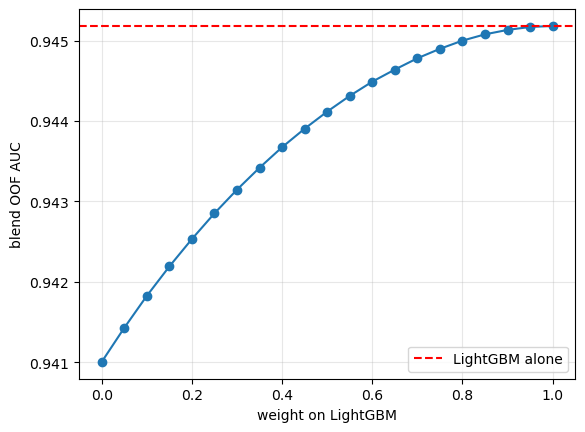

In [72]:
# Sweep blend weights — find the best mix
weights = np.arange(0.0, 1.01, 0.05)
results = []
for w in weights:
    blend = w * lgbm_v4_oof + (1 - w) * cv_xgb["oof"]
    auc = roc_auc_score(y_train, blend)
    results.append((w, auc))

best_w, best_auc = max(results, key=lambda x: x[1])
print(f"Best weight on LightGBM: {best_w:.2f}  →  OOF {best_auc:.4f}")
print(f"LightGBM alone:                       OOF {roc_auc_score(y_train, lgbm_v4_oof):.4f}")
print(f"XGBoost alone:                        OOF {roc_auc_score(y_train, cv_xgb['oof']):.4f}")

# Correlation between the two models' OOF predictions — diversity check
corr = np.corrcoef(lgbm_v4_oof, cv_xgb["oof"])[0, 1]
print(f"\nLGB-XGB OOF correlation: {corr:.4f}")
print("(Lower = more diverse = more potential gain from blending.)")

# Quick visualization
import matplotlib.pyplot as plt
ws, aucs = zip(*results)
plt.plot(ws, aucs, "o-")
plt.axhline(roc_auc_score(y_train, lgbm_v4_oof), color="red", linestyle="--", label="LightGBM alone")
plt.xlabel("weight on LightGBM"); plt.ylabel("blend OOF AUC")
plt.legend(); plt.grid(alpha=0.3); plt.show()


In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MaxAbsScaler

# MaxAbsScaler preserves sparsity (StandardScaler would densify)
scaler = MaxAbsScaler()
X_lr_train = scaler.fit_transform(X_combined_train_v3)
X_lr_test  = scaler.transform(X_combined_test_v3)

# 5-fold CV for LogReg
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_lr = np.zeros(X_lr_train.shape[0])
for tr, va in skf.split(np.zeros(X_lr_train.shape[0]), y_train):
    clf = LogisticRegression(C=1.0, max_iter=1000, solver="saga", n_jobs=-1)
    clf.fit(X_lr_train[tr], y_train[tr])
    oof_lr[va] = clf.predict_proba(X_lr_train[va])[:, 1]

print(f"LogReg OOF: {roc_auc_score(y_train, oof_lr):.4f}")
print(f"LGB-LR correlation: {np.corrcoef(lgbm_v4_oof, oof_lr)[0,1]:.4f}")
print(f"XGB-LR correlation: {np.corrcoef(cv_xgb['oof'], oof_lr)[0,1]:.4f}")

# Refit on full
clf_lr = LogisticRegression(C=1.0, max_iter=1000, solver="saga", n_jobs=-1)
clf_lr.fit(X_lr_train, y_train)
test_prob_lr = clf_lr.predict_proba(X_lr_test)[:, 1]

# 2-model blend: LightGBM v4 + LogReg, weight sweep
weights = np.arange(0.7, 1.01, 0.02)
results = [(w, roc_auc_score(y_train, w*lgbm_v4_oof + (1-w)*oof_lr)) for w in weights]
best_w, best_auc = max(results, key=lambda x: x[1])
print(f"\nBest LGB/LR blend: w_lgb={best_w:.2f}  →  OOF {best_auc:.4f}")
print(f"vs LightGBM alone: {roc_auc_score(y_train, lgbm_v4_oof):.4f}")

LogReg OOF: 0.8806
LGB-LR correlation: 0.8220
XGB-LR correlation: 0.8353

Best LGB/LR blend: w_lgb=1.00  →  OOF 0.9452
vs LightGBM alone: 0.9452


In [74]:
# Path B: fold-averaged test predictions for LightGBM v4
def lgbm_cv_with_test(X, y, X_test, n_splits=5, params=None):
    """5-fold CV that also predicts test from each fold model and averages."""
    p = dict(n_estimators=2000, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    if params: p.update(params)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    aucs, iters = [], []
    oof = np.zeros(X.shape[0])
    test_per_fold = np.zeros((n_splits, X_test.shape[0]))

    for fold, (tr, va) in enumerate(skf.split(np.zeros(X.shape[0]), y)):
        clf = lgb.LGBMClassifier(**p)
        clf.fit(X[tr], y[tr],
                eval_set=[(X[va], y[va])], eval_metric="auc",
                callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
        oof[va] = clf.predict_proba(X[va])[:, 1]
        test_per_fold[fold] = clf.predict_proba(X_test)[:, 1]
        aucs.append(roc_auc_score(y[va], oof[va]))
        iters.append(clf.best_iteration_)
        print(f"Fold {fold+1}: AUC={aucs[-1]:.4f}  best_iter={clf.best_iteration_}")

    print(f"\nMean fold AUC: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
    print(f"OOF AUC      : {roc_auc_score(y, oof):.4f}")
    return {"oof": oof, "test_avg": test_per_fold.mean(axis=0),
            "test_per_fold": test_per_fold, "aucs": aucs, "iters": iters}

bag = lgbm_cv_with_test(X_combined_train_v3, y_train, X_combined_test_v3, params=best_params)

# Compare the two test prediction methods (no AUC, just sanity check on distribution)
print(f"\nSingle refit pred:     mean={test_prob_v4.mean():.4f}, std={test_prob_v4.std():.4f}")
print(f"5-fold-avg pred  :     mean={bag['test_avg'].mean():.4f}, std={bag['test_avg'].std():.4f}")
print(f"Per-row correlation: {np.corrcoef(test_prob_v4, bag['test_avg'])[0,1]:.4f}")

# Write the fold-averaged submission
sub = pd.DataFrame({"index": test["index"].values, "target": bag["test_avg"]})
sub.to_csv(SUB_DIR / "lgbm_v4_foldavg.csv", index=False, float_format="%.6f")
print(f"\nWrote: {SUB_DIR/'lgbm_v4_foldavg.csv'}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[422]	valid_0's auc: 0.948103	valid_0's binary_logloss: 0.266372
Fold 1: AUC=0.9481  best_iter=422
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[542]	valid_0's auc: 0.942917	valid_0's binary_logloss: 0.276489
Fold 2: AUC=0.9429  best_iter=542
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[349]	valid_0's auc: 0.939047	valid_0's binary_logloss: 0.287235
Fold 3: AUC=0.9390  best_iter=349
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[396]	valid_0's auc: 0.948063	valid_0's binary_logloss: 0.263957
Fold 4: AUC=0.9481  best_iter=396
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[420]	valid_0's auc: 0.948282	valid_0's binary_logloss: 0.266298
Fold 5: AUC=0.9483  best_iter=420

Mean fold AUC: 0.9453 ± 

In [75]:
# Add char-level TF-IDF alongside the word-level one
tfidf_char = TfidfVectorizer(
    analyzer="char_wb",          # word-boundary chars (avoids cross-word ngrams)
    ngram_range=(3, 5),          # 3-5 char sequences
    max_features=500,
    min_df=5, max_df=0.95,
    sublinear_tf=True,
    lowercase=True, strip_accents="unicode",
)
Xtc_train = tfidf_char.fit_transform(text_train)
Xtc_test  = tfidf_char.transform(text_test)
print(f"Char TF-IDF: {Xtc_train.shape}")

# Stack: numerics + lang_oh + word-tfidf + char-tfidf
X_v5_train = sparse.hstack([num_train_v3, lang_train_oh, Xt_train, Xtc_train]).tocsr()
X_v5_test  = sparse.hstack([num_test_v3,  lang_test_oh,  Xt_test,  Xtc_test ]).tocsr()
print(f"v5 shape: {X_v5_train.shape}")

cv_v5 = lgbm_cv(X_v5_train, y_train, params=best_params, verbose=True)
print(f"\nv4 OOF (no char): {roc_auc_score(y_train, lgbm_v4_oof):.4f}")
print(f"v5 OOF (+ char) : {roc_auc_score(y_train, cv_v5['oof']):.4f}")

Char TF-IDF: (26206, 500)
v5 shape: (26206, 1039)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[430]	valid_0's auc: 0.947418	valid_0's binary_logloss: 0.268988
Fold 1: AUC=0.9474  best_iter=430
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[372]	valid_0's auc: 0.940925	valid_0's binary_logloss: 0.281003
Fold 2: AUC=0.9409  best_iter=372
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[317]	valid_0's auc: 0.93802	valid_0's binary_logloss: 0.290837
Fold 3: AUC=0.9380  best_iter=317
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[344]	valid_0's auc: 0.945832	valid_0's binary_logloss: 0.269074
Fold 4: AUC=0.9458  best_iter=344
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[279]	valid_0's auc: 0.946001	valid_0's binary_logloss: 0.273061
Fold 5: AU

In [76]:
sn_tfidf = TfidfVectorizer(
    analyzer="char_wb", ngram_range=(2, 4), max_features=200,
    min_df=5, lowercase=True,
)
Xsn_train = sn_tfidf.fit_transform(train["screen_name"].fillna(""))
Xsn_test  = sn_tfidf.transform(test["screen_name"].fillna(""))
print(f"screen_name TF-IDF: {Xsn_train.shape}")

# Stack onto v3 base (NOT v5 — we're discarding char ngrams)
X_v6_train = sparse.hstack([num_train_v3, lang_train_oh, Xt_train, Xsn_train]).tocsr()
X_v6_test  = sparse.hstack([num_test_v3,  lang_test_oh,  Xt_test,  Xsn_test ]).tocsr()
print(f"v6 shape: {X_v6_train.shape}")

cv_v6 = lgbm_cv(X_v6_train, y_train, params=best_params, verbose=False)
print(f"\nv4 OOF (no sn): {roc_auc_score(y_train, lgbm_v4_oof):.4f}")
print(f"v6 OOF (+ sn) : {roc_auc_score(y_train, cv_v6['oof']):.4f}")

screen_name TF-IDF: (26206, 200)
v6 shape: (26206, 739)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[325]	valid_0's auc: 0.945991	valid_0's binary_logloss: 0.272844
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[491]	valid_0's auc: 0.942078	valid_0's binary_logloss: 0.279115
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[301]	valid_0's auc: 0.938917	valid_0's binary_logloss: 0.289546
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[314]	valid_0's auc: 0.946741	valid_0's binary_logloss: 0.268078
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[336]	valid_0's auc: 0.946589	valid_0's binary_logloss: 0.271285

v4 OOF (no sn): 0.9452
v6 OOF (+ sn) : 0.9439


In [77]:
!pip install sentence_transformers

   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------------------- 571.3/571.3 kB 14.5 MB/s  0:00:00
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------- ----------------- 6.0/10.6 MB 28.8 MB/s eta 0:00:01
   ---------------------------------------- 10.6/10.6 MB 28.1 MB/s  0:00:00
   ---------------------------------------- 0.0/661.5 kB ? eta -:--:--
   ---------------------------------------- 661.5/661.5 kB 29.8 MB/s  0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 4.0/4.0 MB 32.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 23.2 MB/s  0:00:00
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   -- ------------------------------------- 5.8/114.6 MB 28.2 MB/s eta 0:00:04
   ---- ----------------------------------

In [78]:
from sentence_transformers import SentenceTransformer

# all-MiniLM-L6-v2 is a small fast model — 384 dims, ~80MB to download once
model = SentenceTransformer("all-MiniLM-L6-v2")

emb_train = model.encode(
    train["description"].fillna("").tolist(),
    batch_size=64, show_progress_bar=True, convert_to_numpy=True,
)
emb_test = model.encode(
    test["description"].fillna("").tolist(),
    batch_size=64, show_progress_bar=True, convert_to_numpy=True,
)
print(f"emb_train: {emb_train.shape}")   # (26206, 384)
print(f"emb_test : {emb_test.shape}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/410 [00:00<?, ?it/s]

Batches:   0%|          | 0/176 [00:00<?, ?it/s]

emb_train: (26206, 384)
emb_test : (11232, 384)


In [79]:
emb_train_sp = sparse.csr_matrix(emb_train)
emb_test_sp  = sparse.csr_matrix(emb_test)

X_v7_train = sparse.hstack([num_train_v3, lang_train_oh, Xt_train, emb_train_sp]).tocsr()
X_v7_test  = sparse.hstack([num_test_v3,  lang_test_oh,  Xt_test,  emb_test_sp]).tocsr()
print(f"v7 shape: {X_v7_train.shape}")   # ~923 features

cv_v7 = lgbm_cv(X_v7_train, y_train, params=best_params, verbose=True)
print(f"\nv4 OOF (no SBERT): {roc_auc_score(y_train, lgbm_v4_oof):.4f}")
print(f"v7 OOF (+ SBERT) : {roc_auc_score(y_train, cv_v7['oof']):.4f}")

v7 shape: (26206, 923)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[462]	valid_0's auc: 0.94491	valid_0's binary_logloss: 0.274585
Fold 1: AUC=0.9449  best_iter=462
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[386]	valid_0's auc: 0.940785	valid_0's binary_logloss: 0.283173
Fold 2: AUC=0.9408  best_iter=386
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[403]	valid_0's auc: 0.938697	valid_0's binary_logloss: 0.291052
Fold 3: AUC=0.9387  best_iter=403
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[535]	valid_0's auc: 0.947554	valid_0's binary_logloss: 0.266783
Fold 4: AUC=0.9476  best_iter=535
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[317]	valid_0's auc: 0.943986	valid_0's binary_logloss: 0.278101
Fold 5: AUC=0.9440  best_iter=317

Me

In [80]:
for ff in [0.3, 0.5, 0.7, 0.85, 1.0]:
    p = dict(best_params); p["feature_fraction"] = ff
    cv = lgbm_cv(X_v7_train, y_train, params=p, verbose=False)
    print(f"feature_fraction={ff}: OOF {roc_auc_score(y_train, cv['oof']):.4f}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[404]	valid_0's auc: 0.943446	valid_0's binary_logloss: 0.278037
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[522]	valid_0's auc: 0.940669	valid_0's binary_logloss: 0.283939
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[402]	valid_0's auc: 0.93832	valid_0's binary_logloss: 0.292087
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[536]	valid_0's auc: 0.946719	valid_0's binary_logloss: 0.268449
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[404]	valid_0's auc: 0.945183	valid_0's binary_logloss: 0.275326
feature_fraction=0.3: OOF 0.9427
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[518]	valid_0's auc: 0.944872	valid_0's binary_logloss: 0.274404
Tr

In [81]:
# Target encoding for lang — replaces the 9-column one-hot with one dense column
# (the smoothed mean bot rate per language).
ALPHA = 10  # smoothing strength: higher = pull rare langs toward global mean

global_mean = y_train.mean()

# Bucket train langs the same way featurize() does, so the encoding mapping
# matches what we'll apply to test (top-8 + OTHER + MISSING fallback).
lang_train_bucketed = train["lang"].fillna("MISSING")
lang_train_bucketed = lang_train_bucketed.where(lang_train_bucketed.isin(TOP_LANGS), "OTHER")

stats = pd.DataFrame({"lang": lang_train_bucketed, "y": y_train})
grp = stats.groupby("lang")["y"]
counts = grp.count()
means  = grp.mean()
te_map = (counts * means + ALPHA * global_mean) / (counts + ALPHA)
print("Target encoding per lang (smoothed bot rate):")
print(te_map.sort_values())

def lang_to_te(lang_series):
    s = lang_series.fillna("MISSING")
    s = s.where(s.isin(TOP_LANGS), "OTHER")
    return s.map(te_map).fillna(global_mean).values.reshape(-1, 1)

te_train = lang_to_te(train["lang"])
te_test  = lang_to_te(test["lang"])

# Two variants to test: "add alongside one-hot" vs "replace one-hot"
# v8a: ADD the target encoding column ALONGSIDE the existing one-hot
X_v8a_train = sparse.hstack([num_train_v3, lang_train_oh, sparse.csr_matrix(te_train), Xt_train]).tocsr()
X_v8a_test  = sparse.hstack([num_test_v3,  lang_test_oh,  sparse.csr_matrix(te_test),  Xt_test ]).tocsr()

# v8b: REPLACE the one-hot with the target encoding column (cleaner, fewer features)
X_v8b_train = sparse.hstack([num_train_v3, sparse.csr_matrix(te_train), Xt_train]).tocsr()
X_v8b_test  = sparse.hstack([num_test_v3,  sparse.csr_matrix(te_test),  Xt_test ]).tocsr()

print(f"\nv8a (one-hot + TE): {X_v8a_train.shape}")
print(f"v8b (TE only)     : {X_v8b_train.shape}")

cv_v8a = lgbm_cv(X_v8a_train, y_train, params=best_params, verbose=False)
cv_v8b = lgbm_cv(X_v8b_train, y_train, params=best_params, verbose=False)

print(f"\nv4 (one-hot only)  OOF: {roc_auc_score(y_train, lgbm_v4_oof):.4f}")
print(f"v8a (one-hot + TE) OOF: {roc_auc_score(y_train, cv_v8a['oof']):.4f}")
print(f"v8b (TE only)      OOF: {roc_auc_score(y_train, cv_v8b['oof']):.4f}")

Target encoding per lang (smoothed bot rate):
lang
de       0.240879
es       0.242516
en       0.246321
it       0.265272
fr       0.273002
pt       0.306048
ja       0.492013
OTHER    0.499304
ar       0.658957
Name: y, dtype: float64

v8a (one-hot + TE): (26206, 540)
v8b (TE only)     : (26206, 531)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[444]	valid_0's auc: 0.948199	valid_0's binary_logloss: 0.266226
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[472]	valid_0's auc: 0.942513	valid_0's binary_logloss: 0.277352
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[301]	valid_0's auc: 0.938871	valid_0's binary_logloss: 0.288314
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[455]	valid_0's auc: 0.948049	valid_0's binary_logloss: 0.264139
Training until validation scores don't improve for 5

In [82]:
def add_interactions(df_features: pd.DataFrame) -> pd.DataFrame:
    """Add hand-crafted interactions between top predictors."""
    out = df_features.copy()

    # Verified status × follower scale: verified-but-no-followers is suspicious
    out["verified_x_log_followers"] = df_features["verified"] * df_features["log_followers_count"]

    # Default profile + has description: bots are lazy on one but not the other
    out["default_x_has_desc"] = df_features["default_profile"] * df_features["has_description"]
    out["default_img_x_default_prof"] = df_features["default_profile_image"] * df_features["default_profile"]

    # Follow/friend imbalance — log ratio (log(followers) - log(friends))
    # Big positive = celebrity-like; big negative = follow-everybody pattern
    out["log_follow_friend_diff"] = df_features["log_followers_count"] - df_features["log_friends_count"]

    # Activity rate vs account age
    out["log_activity_per_age"] = (
        df_features["log_statuses_count"] - np.log1p(df_features["account_age_days"])
    )

    # Verified × default profile — verified accounts almost never have default profile
    out["verified_x_default"] = df_features["verified"] * df_features["default_profile"]

    # Description length × default profile — lazy bots: default profile + empty bio
    out["default_x_desc_len"] = df_features["default_profile"] * df_features["desc_len"]

    # Followers per friend × statuses per day — combined activity intensity
    out["activity_intensity"] = df_features["followers_per_friend"] * df_features["statuses_per_day"]

    return out

X_v9_train = add_interactions(X_v3_train)
X_v9_test  = add_interactions(X_v3_test)
new_cols = [c for c in X_v9_train.columns if c not in X_v3_train.columns]
print(f"Added interactions: {new_cols}")
print(f"v9 shape: {X_v9_train.shape}")

# Rebuild sparse matrix
numeric_cols_v9 = [c for c in X_v9_train.columns if c != "lang"]
num_train_v9 = sparse.csr_matrix(X_v9_train[numeric_cols_v9].fillna(0).values)
num_test_v9  = sparse.csr_matrix(X_v9_test[numeric_cols_v9].fillna(0).values)

X_combined_train_v9 = sparse.hstack([num_train_v9, lang_train_oh, Xt_train]).tocsr()
X_combined_test_v9  = sparse.hstack([num_test_v9,  lang_test_oh,  Xt_test ]).tocsr()
print(f"combined v9: {X_combined_train_v9.shape}")

cv_v9 = lgbm_cv(X_combined_train_v9, y_train, params=best_params, verbose=False)
print(f"\nv4 OOF (no interactions): {roc_auc_score(y_train, lgbm_v4_oof):.4f}")
print(f"v9 OOF (+ interactions) : {roc_auc_score(y_train, cv_v9['oof']):.4f}")

Added interactions: ['verified_x_log_followers', 'default_x_has_desc', 'default_img_x_default_prof', 'log_follow_friend_diff', 'log_activity_per_age', 'verified_x_default', 'default_x_desc_len', 'activity_intensity']
v9 shape: (26206, 39)
combined v9: (26206, 547)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[377]	valid_0's auc: 0.947873	valid_0's binary_logloss: 0.267211
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[434]	valid_0's auc: 0.942406	valid_0's binary_logloss: 0.277169
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[325]	valid_0's auc: 0.938688	valid_0's binary_logloss: 0.288413
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[507]	valid_0's auc: 0.94802	valid_0's binary_logloss: 0.26398
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration i

In [83]:
pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 3.0 MB/s eta 0:00:34
   ---------------------------------------- 0.8/100.2 MB 3.0 MB/s eta 0:00:33
    --------------------------------------- 1.3/100.2 MB 2.0 MB/s eta 0:00:51
    --------------------------------------- 2.1/100.2 MB 2.5 MB/s eta 0:00:40
    --------------------------------------- 2.4/100.2 MB 2.4 MB/s eta 0:00:41
   - -------------------------------------- 2.6/100.2 MB 2.2 MB/s eta 0:00:45
   - -------------------------------------- 3.1/100.2 MB 2.2 MB/s eta 0:00:44
   - -------------------------------------- 3.7/100.2 MB 2.2 MB/s eta 0:00:44
   - -------------------------------------- 4.2/100.2 MB 2.2 MB/s eta 0:00:43
   - -------------------------------------- 4.7/100.2 MB 2.3 MB/s eta 0:00:42
   -- ------------------------------------- 5.2/100.2 MB 2.3 MB/s eta 0:00:42
   -- ------------------------------------- 5.8/100.2 MB 2.3 MB/s eta 0

In [84]:
from catboost import CatBoostClassifier

def cb_cv(X, y, X_test, n_splits=5, params=None, verbose=True):
    """5-fold CV with CatBoost + early stopping. X is a DataFrame, lang is categorical."""
    p = dict(
        iterations=2000,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3.0,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        early_stopping_rounds=50,
        verbose=False,
        task_type="CPU",
    )
    if params: p.update(params)

    cat_features = ["lang"]
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    aucs, iters = [], []
    oof = np.zeros(len(X))
    test_per_fold = np.zeros((n_splits, len(X_test)))

    for fold, (tr, va) in enumerate(skf.split(np.zeros(len(X)), y)):
        clf = CatBoostClassifier(**p)
        clf.fit(
            X.iloc[tr], y[tr],
            eval_set=(X.iloc[va], y[va]),
            cat_features=cat_features,
            use_best_model=True,
        )
        oof[va] = clf.predict_proba(X.iloc[va])[:, 1]
        test_per_fold[fold] = clf.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y[va], oof[va])
        aucs.append(auc); iters.append(clf.best_iteration_)
        if verbose:
            print(f"Fold {fold+1}: AUC={auc:.4f}  best_iter={clf.best_iteration_}")

    aucs = np.array(aucs)
    if verbose:
        print(f"\nMean fold AUC: {aucs.mean():.4f} ± {aucs.std():.4f}")
        print(f"OOF AUC      : {roc_auc_score(y, oof):.4f}")
    return {"oof": oof, "test_avg": test_per_fold.mean(axis=0),
            "aucs": aucs, "iters": iters}

# X_v3_train is the dense pandas DataFrame (numerics + temporal + lang)
cb_result = cb_cv(X_v3_train, y_train, X_v3_test)

print(f"\nLightGBM v4 OOF: {roc_auc_score(y_train, lgbm_v4_oof):.4f}")
print(f"CatBoost    OOF: {roc_auc_score(y_train, cb_result['oof']):.4f}")
print(f"LGB-CB correlation: {np.corrcoef(lgbm_v4_oof, cb_result['oof'])[0,1]:.4f}")

Fold 1: AUC=0.9433  best_iter=839
Fold 2: AUC=0.9386  best_iter=884
Fold 3: AUC=0.9345  best_iter=486
Fold 4: AUC=0.9409  best_iter=562
Fold 5: AUC=0.9429  best_iter=623

Mean fold AUC: 0.9400 ± 0.0032
OOF AUC      : 0.9400

LightGBM v4 OOF: 0.9452
CatBoost    OOF: 0.9400
LGB-CB correlation: 0.9775


Best LGB/CB blend: w_lgb=0.82  →  OOF 0.9455
vs LightGBM alone:                       0.9452
Lift: +0.00030


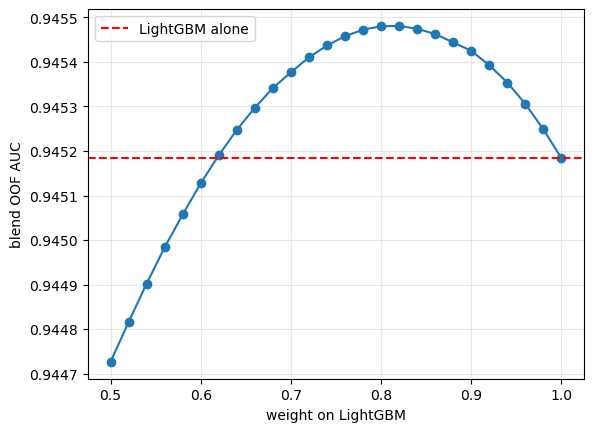

In [85]:
weights = np.arange(0.5, 1.01, 0.02)
results = [(w, roc_auc_score(y_train, w*lgbm_v4_oof + (1-w)*cb_result["oof"])) for w in weights]
best_w, best_auc = max(results, key=lambda x: x[1])
print(f"Best LGB/CB blend: w_lgb={best_w:.2f}  →  OOF {best_auc:.4f}")
print(f"vs LightGBM alone:                       {roc_auc_score(y_train, lgbm_v4_oof):.4f}")
print(f"Lift: {best_auc - roc_auc_score(y_train, lgbm_v4_oof):+.5f}")

import matplotlib.pyplot as plt
ws, aucs = zip(*results)
plt.plot(ws, aucs, "o-")
plt.axhline(roc_auc_score(y_train, lgbm_v4_oof), color="red", linestyle="--", label="LightGBM alone")
plt.xlabel("weight on LightGBM"); plt.ylabel("blend OOF AUC")
plt.legend(); plt.grid(alpha=0.3); plt.show()

In [86]:
W_LGB = 0.82
ensemble_test = W_LGB * test_prob_v4 + (1 - W_LGB) * cb_result["test_avg"]

sub = pd.DataFrame({"index": test["index"].values, "target": ensemble_test})
sub.to_csv(SUB_DIR / "ensemble_lgb_cb.csv", index=False, float_format="%.6f")
print(f"Wrote: {SUB_DIR/'ensemble_lgb_cb.csv'}")
print(f"Weights: {W_LGB:.2f} LGB + {1-W_LGB:.2f} CB")
print(f"Predicted bot rate: {ensemble_test.mean():.4f}")
sub.head()

Wrote: C:\Users\user\Desktop\6. AML\AML_rep\q5_kaggle\submissions\ensemble_lgb_cb.csv
Weights: 0.82 LGB + 0.18 CB
Predicted bot rate: 0.3238


,index,target
0,0,0.009400
1,1,0.872478
2,2,0.057262
3,3,0.040151
4,4,0.984768


In [87]:
import joblib
import optuna

def objective_v7(trial):
    params = dict(
        learning_rate    = trial.suggest_float("learning_rate", 0.015, 0.10, log=True),
        num_leaves       = trial.suggest_int("num_leaves", 31, 255),
        min_data_in_leaf = trial.suggest_int("min_data_in_leaf", 5, 60),
        feature_fraction = trial.suggest_float("feature_fraction", 0.3, 1.0),
        bagging_fraction = trial.suggest_float("bagging_fraction", 0.5, 1.0),
        bagging_freq     = trial.suggest_int("bagging_freq", 1, 10),
        lambda_l2        = trial.suggest_float("lambda_l2", 1e-3, 50.0, log=True),
    )
    cv = lgbm_cv(X_v7_train, y_train, params=params, verbose=False)
    return roc_auc_score(y_train, cv["oof"])

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study_v7 = optuna.create_study(direction="maximize", sampler=sampler,
                                study_name="lgbm_v7_sbert_tuning")

# Save study every 10 trials so we can recover from kernel restarts
def save_callback(study, trial):
    if trial.number % 10 == 9:
        joblib.dump(study, SUB_DIR.parent / "study_v7.pkl")

N_TRIALS = 100
study_v7.optimize(objective_v7, n_trials=N_TRIALS, show_progress_bar=True,
                  callbacks=[save_callback])
joblib.dump(study_v7, SUB_DIR.parent / "study_v7.pkl")  # final save

print(f"\nBest OOF AUC: {study_v7.best_value:.4f}")
print(f"v4 baseline (no SBERT): 0.9452")
print(f"Lift: {study_v7.best_value - 0.9452:+.4f}")
print(f"\nBest params:")
for k, v in study_v7.best_params.items():
    print(f"  {k}: {v}")

[I 2026-05-07 13:40:43,870] A new study created in memory with name: lgbm_v7_sbert_tuning


  0%|          | 0/100 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[312]	valid_0's auc: 0.942354	valid_0's binary_logloss: 0.281165
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[372]	valid_0's auc: 0.939304	valid_0's binary_logloss: 0.286769
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[343]	valid_0's auc: 0.935735	valid_0's binary_logloss: 0.298139
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[327]	valid_0's auc: 0.945122	valid_0's binary_logloss: 0.273674
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[408]	valid_0's auc: 0.943138	valid_0's binary_logloss: 0.279352
[I 2026-05-07 13:42:23,717] Trial 0 finished with value: 0.9410091770619502 and parameters: {'learning_rate': 0.019396400432382138, 'num_leaves': 230, 'min_data_in_leaf': 57, 'feature_fraction': 

tset
